# Evaluación 2

**Integrante 1:** Bastián Cid

**Integrante 2:** Javiera Carrasco

**Correo Electrónico integrante 1:** bastian.cid2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** javiera.carrasco2201@alumnos.ubiobio.cl

**Fecha de Creación:** Mayo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [41]:
!git clone https://github.com/javimiau/IA-620454.git

Cloning into 'IA-620454'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 21 (delta 2), reused 17 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 3.97 MiB | 18.05 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [42]:
import os
os.chdir('IA-620454')
print(os.getcwd())

/content/IA-620454/IA-620454/IA-620454/IA-620454


In [43]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

path_dataset = os.path.join('data', 'ingestion', 'E2-Ingestion.csv')
data_retail = pd.read_csv(path_dataset)
data_retail.head()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890


In [44]:
print(data_retail.shape)
print(data_retail.dtypes)
data_retail.info()

(25500, 11)
id_tienda               int64
tamano_tienda         float64
antiguedad_tienda       int64
temperatura           float64
precio_combustible    float64
indice_economico      float64
semana                  int64
es_feriado              int64
clientes_estimados    float64
tipo_tienda            object
ventas_semanales      float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_tienda           25500 non-null  int64  
 1   tamano_tienda       25500 non-null  float64
 2   antiguedad_tienda   25500 non-null  int64  
 3   temperatura         24224 non-null  float64
 4   precio_combustible  24221 non-null  float64
 5   indice_economico    25500 non-null  float64
 6   semana              25500 non-null  int64  
 7   es_feriado          25500 non-null  int64  
 8   clientes_estimados  24220 non-null  floa

#Preparación de datos

In [45]:
# variable objetivo
y = data_retail['ventas_semanales']

# variables predictoras (se excluye también el id de la tienda)
X = data_retail.drop(columns=['ventas_semanales', 'id_tienda'])

# tipos de variables
numericas = ['tamano_tienda', 'antiguedad_tienda', 'temperatura',
             'precio_combustible', 'indice_economico', 'semana',
             'clientes_estimados', 'es_feriado']

categoricas = ['tipo_tienda']

print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)
print("X:", X.shape)
print("y:", y.shape)

Variables numéricas: ['tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible', 'indice_economico', 'semana', 'clientes_estimados', 'es_feriado']
Variables categóricas: ['tipo_tienda']
X: (25500, 9)
y: (25500,)


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (20400, 9)
Test: (5100, 9)


In [47]:
# pipeline para variables numéricas
pipe_numericas = Pipeline([
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline para variables categóricas
pipe_categoricas = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# unificación de transformaciones
preprocesador = ColumnTransformer([
    ('num', pipe_numericas, numericas),
    ('cat', pipe_categoricas, categoricas)
])

# preprocesamiento + Modelo de regresión juntos
pipeline_final = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo_regresion', LinearRegression())
])

# entrenamiento automático de todo el flujo
pipeline_final.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer_num',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tamano_tienda',
                                                   'antiguedad_tienda',
                                                   'temperatura',
                                                   'precio_combustible',
                                                   'indice_economico', 'semana',
                                                   'clientes_estimados',
                                                   'es_feriado']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['tipo_tienda'])])),
                ('modelo_regresion', LinearRegression())])

#Modelamiento de datos

In [48]:
from sklearn.linear_model import LinearRegression, Ridge

modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0)
}

pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline([
        ('preprocesamiento', preprocesador),
        ('modelo', modelo)
    ])

    pipeline.fit(X_train, y_train)

    pipelines_entrenados[nombre] = pipeline

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"{'Modelo':<25} {'MAE':>12} {'R²':>10}")
print("-" * 50)

resultados = {}
for nombre, pipe in pipelines_entrenados.items():
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    resultados[nombre] = {'MAE': mae, 'R²': r2}
    print(f"{nombre:<25} {mae:>12.2f} {r2:>10.4f}")

Modelo                             MAE         R²
--------------------------------------------------
Linear Regression              4950.82     0.5593
Ridge (alpha=0.1)              4950.82     0.5593
Ridge (alpha=1.0)              4950.80     0.5593
Ridge (alpha=10.0)             4950.60     0.5593


-Todos los modelos obtienen un MAE cercano a 4.950, lo que significa que en promedio el modelo se equivoca en 4.950 en su predicción de ventas semanales.

-El R² de 0.5593 indica que el modelo explica aproximadamente el 56% de la variabilidad en las ventas semanales.

-Las diferencias entre LinearRegression y Ridge no son significativas en este caso. Esto indica que no hay multicolinealidad importante entre las variables,
por lo que la regularización de Ridge no aporta mejora relevante.

-Para efectos prácticos, cualquiera de los modelos es equivalente.
Se selecciona Linear Regression por su mayor interpretabilidad.

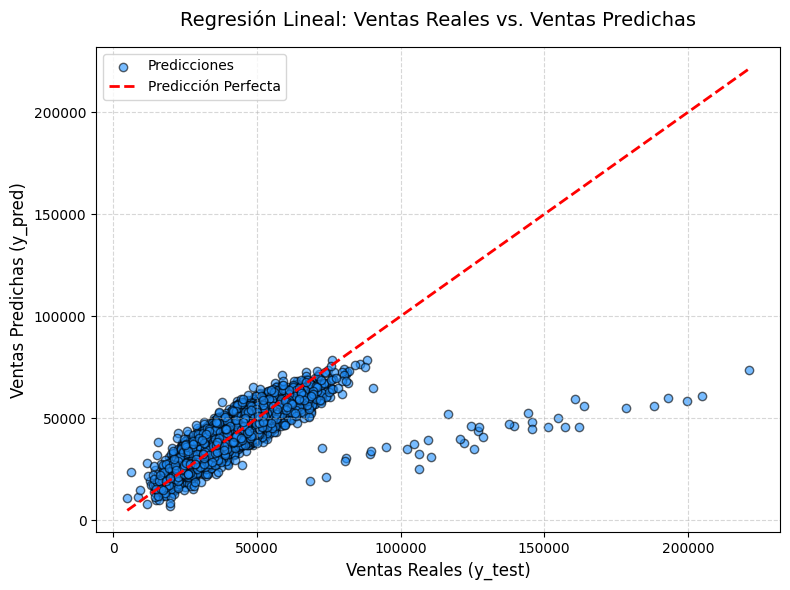

In [50]:
import matplotlib.pyplot as plt

mejor_modelo = pipelines_entrenados['Linear Regression']
y_pred_mejor = mejor_modelo.predict(X_test)

plt.figure(figsize=(8, 6))

# dibujar los puntos (Valores Reales vs Valores Predichos)
plt.scatter(y_test, y_pred_mejor, alpha=0.6, color='dodgerblue', edgecolors='k', label='Predicciones')

# dibujar la línea de "predicción Perfecta" (diagonal roja)
min_val = min(y_test.min(), y_pred_mejor.min())
max_val = max(y_test.max(), y_pred_mejor.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

# etiquetas, título y detalles visuales
plt.title('Regresión Lineal: Ventas Reales vs. Ventas Predichas', fontsize=14, pad=15)
plt.xlabel('Ventas Reales (y_test)', fontsize=12)
plt.ylabel('Ventas Predichas (y_pred)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# mostrar el gráfico
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

ohe_categorias = pipelines_entrenados['Linear Regression'] \
    .named_steps['preprocesamiento'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categoricas)

nombres_features = numericas + list(ohe_categorias)

coeficientes = pipelines_entrenados['Linear Regression'] \
    .named_steps['modelo'] \
    .coef_

# crear dataframe ordenado
df_coef = pd.DataFrame({
    'Variable': nombres_features,
    'Coeficiente': coeficientes
}).sort_values('Coeficiente', key=abs, ascending=False)

print(df_coef.to_string(index=False))

          Variable  Coeficiente
     tamano_tienda  8591.094420
     tipo_tienda_A  8102.147537
     tipo_tienda_C -8091.256903
clientes_estimados  1620.443880
        es_feriado  1581.726636
  indice_economico   594.180962
            semana    48.020385
       temperatura   -33.656850
     tipo_tienda_B   -10.890634
precio_combustible    -5.021349
 antiguedad_tienda     4.236085


**Variables más influyentes**

-`tamano_tienda` (coef: +8.591) es la variable con mayor impacto positivo: Por cada unidad adicional de metro cuadrado, las ventas semanales aumentan en 8.591.
Tiendas más grandes generan significativamente más ventas.

-`tipo_tienda_A` (coef: +8.102) y `tipo_tienda_C` (coef: -8.091) muestran el fuerte impacto del tipo de tienda. Las tiendas tipo A (grandes, alta demanda) venden 8.102 más que la categoría de referencia, mientras que las tipo C (pequeñas) venden $8.091 menos. Esto es consistente con la descripción del dataset.
El tipo B tiene un coeficiente prácticamente nulo (-10), confirmando que actúa como categoría intermedia de referencia.

-`clientes_estimados` (coef: +1.620): a mayor número de clientes estimados en la semana, mayores ventas, lo cual es lógico y esperado.

-`es_feriado` (coef: +1.581): las semanas con feriado tienen ventas más altas, lo que sugiere mayor actividad de compra en esos períodos.

-`precio_combustible` y `temperatura` tienen coeficientes muy bajos (-5 y -33 respectivamente), lo que indica que su influencia sobre las ventas es mínima en comparación con las variables estructurales de la tienda.

# Predicción de nuevos registros

In [52]:
import pandas as pd

# creación de datos nuevos simulados para la predicción.
nuevos_datos = pd.DataFrame({
    'tamano_tienda': [2000, 500],
    'antiguedad_tienda': [10, 2],
    'temperatura': [20.0, 20.0],
    'precio_combustible': [1000, 1000],
    'indice_economico': [105, 105],
    'semana': [40, 40],
    'clientes_estimados': [4500, 800],
    'es_feriado': [1, 1],
    'tipo_tienda': ['A', 'C']
})

print("Nuevos registros a predecir:")
display(nuevos_datos)

# seleccionamos el modelo de regresión lineal
mejor_modelo = pipelines_entrenados['Linear Regression']

# generamos las predicciones
predicciones_nuevas = mejor_modelo.predict(nuevos_datos)

# mostramos los resultados
resultados_prediccion = nuevos_datos.copy()
resultados_prediccion['ventas_predichas'] = predicciones_nuevas

print("\nResultados de la predicción:")
display(resultados_prediccion[['tipo_tienda', 'tamano_tienda', 'clientes_estimados', 'ventas_predichas']])

Nuevos registros a predecir:


,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,clientes_estimados,es_feriado,tipo_tienda
0,2000,10,20.0,1000,105,40,4500,1,A
1,500,2,20.0,1000,105,40,800,1,C



Resultados de la predicción:


,tipo_tienda,tamano_tienda,clientes_estimados,ventas_predichas
0,A,2000,4500,118174.394463
1,C,500,800,7429.824946


**Interpretación de los resultados:**

Al aplicar nuestro modelo sobre estos nuevos registros, los resultados son totalmente coherentes con los coeficientes obtenidos en el análisis previo.

El modelo proyecta un volumen de ventas drásticamente mayor para la primera tienda. Esto se debe a que el algoritmo ha aprendido a premiar fuertemente las sucursales de la categoría "A" (que mostraron un coeficiente positivo de +8.102) y que además cuentan con mayor `tamano_tienda` y `clientes_estimados`. Por el contrario, la tienda pequeña de tipo "C" sufre una penalización en su estimación de ventas semanales, demostrando que el modelo ha capturado correctamente la lógica estructural del negocio basándose en los datos históricos.

### Pregunta de reflexión

**¿En qué situación preferiría utilizar Ridge en lugar de Linear Regression?**

-Preferiría utilizar la regresión de Ridge por sobre la *Linear Regression* clásica en los siguientes escenarios críticos:

-Presencia de multicolinealidad: Cuando las variables predictoras están altamente correlacionadas entre sí (por ejemplo, si tuviéramos variables redundantes como "tráfico peatonal" y "clientes estimados"). En una Regresión Lineal estándar, la multicolinealidad infla la varianza de los coeficientes, haciéndolos inestables y poco confiables. Ridge aplica una penalización (Regularización L2) que distribuye los pesos entre estas variables correlacionadas, mitigando el problema.


-Complejidad del modelo (Alta dimensionalidad): Si el conjunto de datos tuviera cientos de variables (por ejemplo, datos demográficos hiper-detallados por tienda), un modelo de Regresión Lineal intentaría ajustarse a todo el ruido de los datos de entrenamiento, cayendo en overfitting (sobreajuste). Ridge reduce la complejidad del modelo al encoger los coeficientes de las variables menos importantes hacia cero, priorizando la generalización sobre datos no vistos.

-Estabilidad frente a anomalías: La regresión clásica es muy sensible; un pequeño cambio en los datos de entrenamiento puede alterar drásticamente la línea de predicción. Al penalizar los coeficientes excesivamente grandes, Ridge le otorga una mayor estabilidad matemática al modelo, logrando que las predicciones sean más robustas y consistentes.

In [53]:
# Guardar el resultado final de tu limpieza
from google.colab import files
df_coef.to_csv('E2-Cleaned.csv', index=False)
files.download('E2-Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>